# Electricity Consumption Forecasting with LSTM Neural Networks

## Project Objective

To develop a predictive model using LSTM neural networks that accurately forecasts hourly electricity consumption based on historical usage data, enabling efficient energy management, load planning, and demand forecasting.

## Dataset Information
This project uses an aggregated hourly electricity consumption dataset derived from the UCI Electricity Load Diagrams dataset. It contains 321 household-level time series spanning 2012–2014, with each series representing continuous hourly electricity usage. The data is well suited for short-term load forecasting using LSTM networks.

### Dataset Structure: Rows and Columns
| **Component**         | **Description**                                                                                                                                                       |
| --------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Rows**              | Each row represents a single household (client). Every row corresponds to one independent hourly electricity consumption time series (e.g., T1, T2, …, T321). |
| **Column 0**          | Household ID – a unique identifier for each household (T1–T321).                                                                                                  |
| **Column 1**          | Start Timestamp / Metadata – indicates the starting time of the series; not directly used for LSTM modeling.                                                      |
| **Columns 2 – 26304** | Hourly Electricity Consumption Values measured in kilowatts (kW). Each column corresponds to one hourly time step                                             |
| **Total Rows**        | 321 households (321 independent time series).                                                                                                                         |
| **Total Columns**     | ~26,305 columns, including ID, timestamp, and hourly readings.                                                                                                        |
| **Time Resolution**   | Hourly (aggregated from original 15-minute intervals).                                                                                                                |
| **Data Type**         | Univariate time series per household (one feature: electricity consumption).                                                                                          |



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


### Python Function to Convert TSF → CSV

In [2]:

def tsf_to_csv(tsf_file, csv_file):
    with open(tsf_file, 'r') as f:
        lines = f.readlines()

    # Skip metadata (lines starting with @)
    data_lines = [line.strip() for line in lines if not line.startswith('@') and line.strip() != '']

    # Split each line by ":" or "," depending on TSF file format
    # TSF files have format: class_label:series_values
    rows = []
    for line in data_lines:
        if ':' in line:
            label, series = line.split(':', 1)
            values = series.split(',')  # adjust separator if needed
            rows.append([label] + values)
        else:
            # if no label, just split values
            rows.append(line.split(','))

    # Create DataFrame
    df = pd.DataFrame(rows)

    # Save as CSV
    df.to_csv(csv_file, index=False, header=False)

# # Example usage
# tsf_to_csv("your_file.tsf", "output_file.csv")


The tsf_to_csv function converts a .tsf time series file into a CSV by skipping metadata, splitting each line into labels and values, and saving the data in a Pandas DataFrame for easy analysis and modeling.

In [3]:
# tsf_to_csv('D:\\ds ai ml\\DS@AI\\00-portfolio-projects\\06-LSTM-Electricity Consumption Forecasting\\electricity_hourly_dataset.tsf','D:\\ds ai ml\\DS@AI\\00-portfolio-projects\\06-LSTM-Electricity Consumption Forecasting\\eb.csv')

## Load data

In [4]:
data = pd.read_csv(
                   r'D:\ds ai ml\DS@AI\00-portfolio-projects\06-LSTM-Electricity Consumption Forecasting\eb.csv', 
                   header = None, 
                   # comment ='#' # skip lines starting with #,
                   skiprows = 10
                  )
data.head(5)

,0,1,2,3,4,5,6,7,8,9,...,26295,26296,26297,26298,26299,26300,26301,26302,26303,26304
0,T1,2012-01-01 00-00-01:14,18,21,20,22,20,20,20,13,...,8,17,13,10,11,11,11,12,10,11
1,T2,2012-01-01 00-00-01:69,92,96,92,91,92,91,92,91,...,109,117,118,115,117,116,103,93,92,88
2,T3,2012-01-01 00-00-01:234,312,312,312,312,187,138,8,7,...,7,7,8,10,12,8,8,8,8,8
3,T4,2012-01-01 00-00-01:415,556,560,443,346,340,376,361,259,...,550,564,620,669,830,844,749,650,646,648
4,T5,2012-01-01 00-00-01:215,292,272,213,190,178,199,187,144,...,259,245,267,274,351,384,371,346,349,337


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Columns: 26305 entries, 0 to 26304
dtypes: float64(24), int64(26279), object(2)
memory usage: 64.4+ MB


# Further time series analysis is performed on a single household (T1).

In [6]:
ts = data.iloc[0:1,2:].values.reshape(-1,1)

In [7]:
ts.shape

(26303, 1)

### Visualize the Time Series data

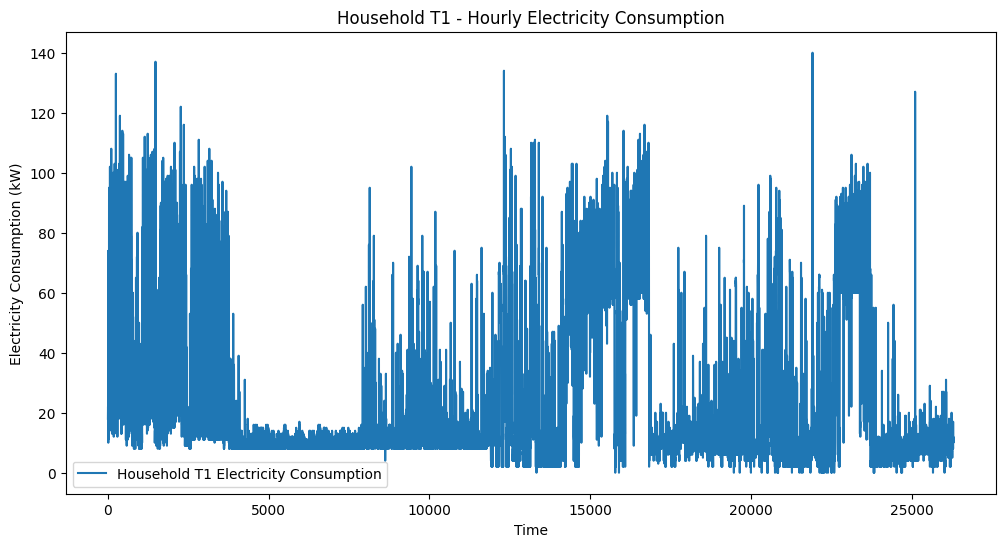

In [8]:
plt.figure(figsize=(12,6))
plt.plot(ts, label='Household T1 Electricity Consumption')
plt.title('Household T1 - Hourly Electricity Consumption')
plt.xlabel('Time')
plt.ylabel('Electricity Consumption (kW)')
plt.legend()
plt.show()


## Data Preprocessing

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(ts)

In [10]:
len(scaled_data)

26303

In [11]:
# create sequence for LSTM
sequence_length=24 # past 24 hours to  predict next hour
x,y=[],[]

for i in range(sequence_length, len(scaled_data)):
  x.append(scaled_data[i-sequence_length:i])
  y.append(scaled_data[i])


In [12]:
x,y=np.array(x),np.array(y)

In [13]:
print(x.shape)
print(y.shape)

(26279, 24, 1)
(26279, 1)


### train test split

In [14]:
split = int(0.8 * len(x))
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]


## Model building

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [16]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(x.shape[1], 1)))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Define early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',   # Monitor validation loss
    patience=5,          # Stop after 5 epochs with no improvements
    restore_best_weights=True  # Restore weights from the epoch with the best value
)

In [18]:
## train the model
history = model.fit(x_train, y_train,
                    epochs=20, 
                    batch_size=32,
                    validation_data=(x_test, y_test),
                    callbacks=[early_stop],
                    verbose=1,
                    shuffle = False     # critical for time series 
                   )



Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - loss: 0.0102 - mae: 0.0586 - val_loss: 0.0055 - val_mae: 0.0439
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - loss: 0.0086 - mae: 0.0525 - val_loss: 0.0046 - val_mae: 0.0389
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0079 - mae: 0.0497 - val_loss: 0.0042 - val_mae: 0.0357
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - loss: 0.0073 - mae: 0.0478 - val_loss: 0.0041 - val_mae: 0.0355
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - loss: 0.0071 - mae: 0.0462 - val_loss: 0.0039 - val_mae: 0.0340
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - loss: 0.0070 - mae: 0.0456 - val_loss: 0.0038 - val_mae: 0.0331
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - loss: 0.0069 - mae: 0.0453 - val_loss: 0.0038 - val_mae: 0.0352
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - loss: 0.0068 - mae: 0.0449 - val_loss: 0.0038 - val_mae: 0.0324
Epoch 9/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 

### Plot training loss

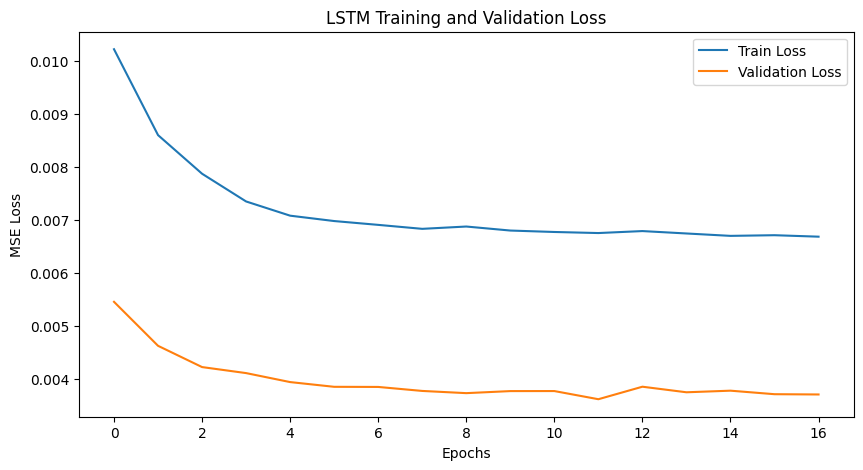

In [19]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


### Training vs Validation Loss:
- The LSTM model’s training and validation loss steadily decrease and remain close, indicating good learning and minimal overfitting. By the final epochs, the MAE stabilizes around 0.043 (train) and 0.032 (validation), showing reliable prediction performance.

- The training loss is slightly higher than the validation loss because regularization techniques like dropout are applied during training, but not during evaluation. This adds noise during training, increasing the loss, whereas the full model is evaluated on the validation set, resulting in lower loss

#### Predictions

165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step


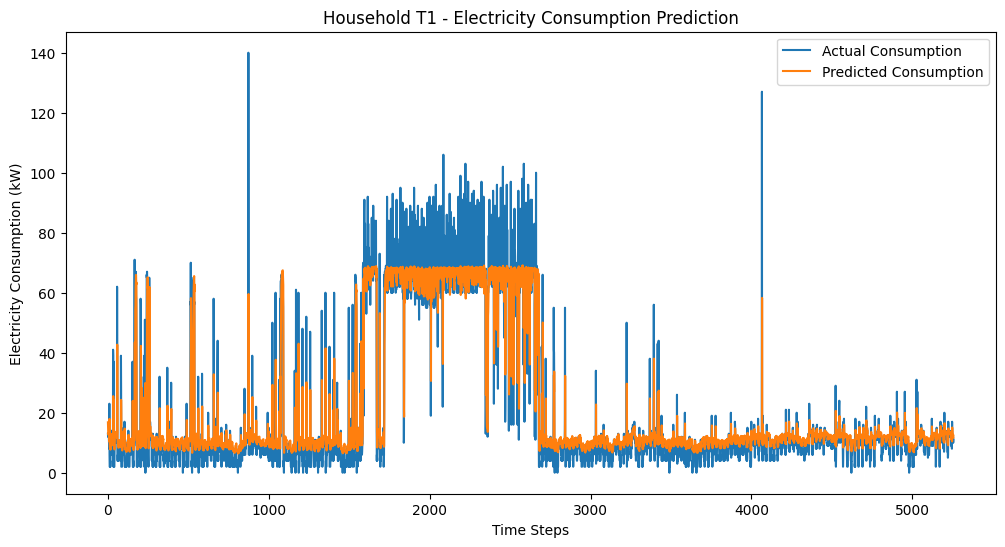

In [20]:
y_pred = model.predict(x_test)

# Inverse transform to original scale
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Actual Consumption')
plt.plot(y_pred_inv, label='Predicted Consumption')
plt.title('Household T1 - Electricity Consumption Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Electricity Consumption (kW)')
plt.legend()
plt.show()


### Model Evaluation

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE: {mae:.2f}")


Test RMSE: 8.42
Test MAE: 4.36


On the test set, model achieves MAE = 4.36 and RMSE = 8.42, indicating good predictive accuracy with occasional larger deviations. Overall, the model generalizes well and provides reliable forecasts for the time series.

## Predict next hour electricity consumption

In [22]:
def predict_next_hour(model,scaled_data, scaler, seq_length=24):
    last_seq = scaled_data[-seq_length:].reshape(1, seq_length, 1)
    pred_scaled = model.predict(last_seq)
    pred_real = scaler.inverse_transform(pred_scaled)
    return pred_real[0][0]


In [23]:
predict_next_hour(model,scaled_data,scaler, 24)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


np.float32(12.116399)

## Final Conclusion

The project successfully developed an LSTM-based neural network model to forecast hourly electricity consumption for individual households using historical time series data. Focusing on a single household (T1), the model was trained on sequences of 24 past hours to predict the next hour’s consumption.


### Key Findings:

- Data Handling & Preprocessing:

    - The dataset consisted of 321 household-level time series with hourly resolution.

    - Data was scaled using MinMaxScaler to improve LSTM convergence.

    - Sequence-based input windows of 24 hours allowed the model to capture short-term temporal dependencies.

- Model Architecture & Training:

    - A two-layer LSTM network with 64 and 32 units, followed by dropout (0.2) and dense layers, was used.

    - Early stopping prevented overfitting, and shuffle was disabled to preserve temporal order.

    - Training and validation losses steadily decreased, with minimal divergence, indicating effective learning and generalization.

- Performance Metrics:

    - The model achieved MAE ≈ 4.36 kW and RMSE ≈ 8.42 kW on the test set.

    - Predicted values closely followed the actual consumption trends, with only occasional larger deviations.
 
- Forecating future data
    - A next-hour prediction function uses the most recent 24 hours of data to forecast electricity consumption. The trained LSTM model generates the prediction, which is inverse-scaled to real-world units (kW), enabling reliable real-time, one-step-ahead forecasting for operational energy management

    
- Observations:

    - The LSTM captured hourly consumption patterns effectively, demonstrating its suitability for short-term load forecasting.

    - Dropout slightly increased training loss compared to validation loss, as expected, due to regularization during training.

    - Visualization confirmed that the model’s predictions tracked real consumption patterns, highlighting reliable forecasting capability.

